## [ML] Analisis Performa Akademik Mahasiswa Melalui Pendekatan Machine Learning: Studi Berbasis Data Kebiasaan dan Kondisi Sosial

In [ ]:
#Target   : Cumulative Grade Point Average (CGPA)
#Models   : Linear Regression (Baseline) + Lasso + Ridge + Random Forest (Main)
#Features : 9 Main Variables (Kebiasaan) + 13 Support Variables (Lingkungan)
#Transform: Log1p pada fitur numerik yang skewed
#Dropped  : SGPA, skill_count, Program, Interested Area, Admission Year, Credit Completed, Suspension, Skills (raw)

In [ ]:
#Import Library
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, probplot

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, FunctionTransformer, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


Load Data & Cheking Info - Membaca data

In [ ]:
#Load Data dari excel
df = pd.read_excel('/content/Students_Performance_data_set (1).xlsx')

In [ ]:
df.shape  #melihat ukuran data

(1194, 31)

In [ ]:
df.info() #melihat variabel, data type, dan apakah ada missing value

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1194 entries, 0 to 1193
Data columns (total 31 columns):
 #   Column                                                                     Non-Null Count  Dtype  
---  ------                                                                     --------------  -----  
 0   University Admission year                                                  1194 non-null   int64  
 1   Gender                                                                     1194 non-null   object 
 2   Age                                                                        1194 non-null   int64  
 3   H.S.C passing year                                                         1194 non-null   int64  
 4   Program                                                                    1194 non-null   object 
 5   Current Semester                                                           1194 non-null   int64  
 6   Do you have meritorious scholarship ?                   

In [ ]:
df.head() #melihat isi dari excel

,University Admission year,Gender,Age,H.S.C passing year,Program,Current Semester,Do you have meritorious scholarship ?,Do you use University transportation?,How many hour do you study daily?,How many times do you seat for study in a day?,...,What is you interested area?,What is your relationship status?,Are you engaged with any co-curriculum activities?,With whom you are living with?,Do you have any health issues?,What was your previous SGPA?,Do you have any physical disabilities?,What is your current CGPA?,How many Credit did you have completed?,What is your monthly family income?
0,2018,Male,24,2016,BCSE,12,Yes,No,3,2,...,Data Schince,Single,Yes,Bachelor,No,2.68,No,3.15,75,25000
1,2021,Male,22,2020,BCSE,4,Yes,Yes,3,2,...,Event management,Single,Yes,Family,No,2.68,No,3.15,36,100000
2,2020,Female,21,2019,BCSE,5,No,No,3,3,...,Software,Single,No,Bachelor,No,2.68,No,3.15,50,50000
3,2021,Male,20,2020,BCSE,4,Yes,No,1,3,...,Artificial Intelligence,Single,No,Bachelor,Yes,2.68,No,3.15,36,62488
4,2021,Male,22,2019,BCSE,4,Yes,No,3,1,...,Software,Relationship,No,Bachelor,Yes,2.68,No,3.15,36,50000


Check Missing Value

In [ ]:
print("Missing Value Check")
df.isnull().sum()

Missing Value Check


,0
University Admission year,0
Gender,0
Age,0
H.S.C passing year,0
Program,0
Current Semester,0
Do you have meritorious scholarship ?,0
Do you use University transportation?,0
How many hour do you study daily?,0
How many times do you seat for study in a day?,0


In [ ]:
df.isnull().sum() / len(df) * 100 #Melihat dalam decimal

,0
University Admission year,0.000000
Gender,0.000000
Age,0.000000
H.S.C passing year,0.000000
Program,0.000000
Current Semester,0.000000
Do you have meritorious scholarship ?,0.000000
Do you use University transportation?,0.000000
How many hour do you study daily?,0.000000
How many times do you seat for study in a day?,0.000000




---



Rename Target Variable (Current GPA) -- agar lebih simple dan mempermudah untuk dipanggil

In [ ]:
if 'What is your current CGPA?' in df.columns:
    df.rename(columns={'What is your current CGPA?': 'CGPA'}, inplace=True) #Rename target

print("\n=== CGPA (Target Variable) ===")
print(df['CGPA'].describe()) #Melakukan pengecheckan mean,std, min,max


=== CGPA (Target Variable) ===
count    1194.000000
mean        3.165600
std         0.750127
min         0.000000
25%         2.900000
50%         3.210000
75%         3.670000
max         4.000000
Name: CGPA, dtype: float64


In [ ]:
# Cek data tidak wajar - diluar batas 0-4
print("\nCheck Data Tidak Wajar (0-4)")
print(df[(df['CGPA'] > 4.0) | (df['CGPA'] < 0.0)])



Check Data Tidak Wajar (0-4)
Empty DataFrame
Columns: [University Admission year, Gender, Age, H.S.C passing year, Program, Current Semester, Do you have meritorious scholarship ?, Do you use University transportation?, How many hour do you study daily?, How many times do you seat for study in a day?, What is your preferable learning mode?, Do you use smart phone?, Do you have personal Computer?, How many hour do you spent daily in social media?, Status of your English language proficiency, Average attendance on class, Did you ever fall in probation?, Did you ever got suspension?, Do you attend in teacher consultancy for any kind of academical problems?, What are the skills do you have ?, How many hour do you spent daily on your skill development?, What is you interested area?, What is your relationship status?, Are you engaged with any co-curriculum activities?, With whom you are living with?, Do you have any health issues?, What was your previous SGPA?, Do you have any physical disa

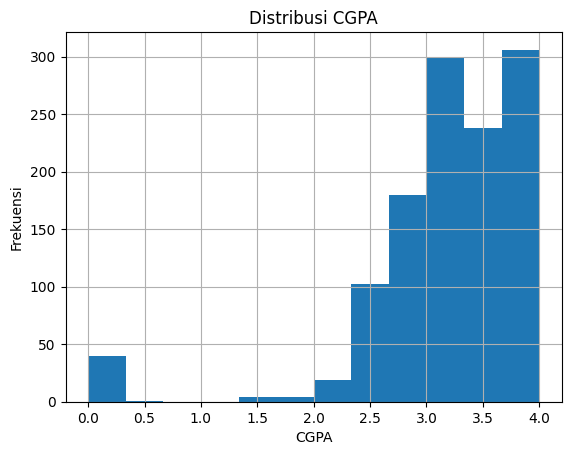

In [ ]:
# Disini akan melihat visualisasi distribusi CGPA
df['CGPA'].hist(bins=12)
plt.title('Distribusi CGPA')
plt.xlabel('CGPA')
plt.ylabel('Frekuensi')
plt.show()

## Berada dalam batas wajar



---



Dropping Column yang tidak digunakan

In [ ]:
# DROP KOLOM YANG TIDAK DIGUNAKAN
# Alasan drop masing-masing kolom:
# - SGPA                : nilai akademik sebelumnya (bukan kebiasaan/lingkungan)
# - Program             : tidak ada variasi (semua BCSE)
# - Interested Area     : terlalu spesifik dan banyak noise
# - Admission Year      : tidak memberikan relevansi langsung terhadap performa
# - Credit Completed    : tidak berpengaruh karena merupakan output/akibat, bukan penyebab
# - Suspension          : hampir semua "No", tidak ada variasi
# - Skills (raw)        : akan di-handle lalu di-drop
# - H.S.C passing year  : tidak memberikan pengaruh

In [ ]:
# Drop column yang tidak dibutuhkan jika ada
drop_column = [
    'What was your previous SGPA?',
    'What is you interested area?',
    'University Admission year',
    'How many Credit did you have completed?',
    'Did you ever got suspension?',
    'H.S.C passing year',
]

In [ ]:
# Drop hanya kolom yang ada di dataframe
drop_column = [ drop for drop in drop_column if drop in df.columns]
df.drop(columns=drop_column, inplace=True)


In [ ]:
# Drop kolom Program jika ada dan tidak ada variasi
if 'Program' in df.columns:
    if df['Program'].nunique() <= 1:
        df.drop(columns=['Program'], inplace=True)
        print("Kolom 'Program' di-drop karena tidak ada variasi.")

print(f"\nKolom yang di-drop: {drop_column}")
print(f"Shape setelah drop: {df.shape}")

Kolom 'Program' di-drop karena tidak ada variasi.

Kolom yang di-drop: ['What was your previous SGPA?', 'What is you interested area?', 'University Admission year', 'How many Credit did you have completed?', 'Did you ever got suspension?', 'H.S.C passing year']
Shape setelah drop: (1194, 24)




---



Handle Kolom SKills --> tidak digunakan dalam model dan tidak berpengaruh

In [ ]:
if 'What are the skills do you have ?' in df.columns:
    df.drop(columns=['What are the skills do you have ?'], inplace=True)

#Asalan :
# Tidak relevan dengan tujuan penelitian (kebiasaan & lingkungan).
# Kebiasaan pengembangan diri sudah diwakili oleh kolom "How many hour do you spent daily on your skill development?"


Cleaning Numeric Column - Main Variable

In [ ]:
numeric_cols = [
    'How many hour do you study daily?',
    'How many times do you seat for study in a day?',
    'How many hour do you spent daily in social media?',
    'How many hour do you spent daily on your skill development?',
]

In [ ]:
#Mengubah menjadi numerik
for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str) #Mengubah ke string
        .str.strip() #Mengahapus spasi
        .str.replace(',', '.', regex=False) #Mengganti koma decimal (Ex: "1,5" → "1.5")
        .str.extract(r'(\d+\.?\d*)')[0]   # Mengambil angka pertama
        .astype(float)
    )


In [ ]:
for col in numeric_cols:
    print(f"\nKolom {col} setelah dibersihkan :")
    print(df[col].describe())


Kolom How many hour do you study daily? setelah dibersihkan :
count    1194.000000
mean        3.131491
std         1.649597
min         0.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        13.000000
Name: How many hour do you study daily?, dtype: float64

Kolom How many times do you seat for study in a day? setelah dibersihkan :
count    1194.000000
mean        1.940536
std         0.856305
min         0.000000
25%         1.000000
50%         2.000000
75%         2.000000
max         7.000000
Name: How many times do you seat for study in a day?, dtype: float64

Kolom How many hour do you spent daily in social media? setelah dibersihkan :
count    1194.000000
mean        3.289782
std         2.289547
min         0.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        20.000000
Name: How many hour do you spent daily in social media?, dtype: float64

Kolom How many hour do you spent daily on your skill development? setelah dibers

Cleaning Categorical Column -- Main Variable

In [ ]:
#1. Average Attendance on Class
print("\n Average attendance on class (Intial)")
df['Average attendance on class'].value_counts()



 Average attendance on class (Intial)


,count
Average attendance on class,
100,357
90,182
95,107
80,93
98,53
...,...
31,1
64,1
24,1


In [ ]:
#Membersihkan
#Melakukan ekstrak angka dari nilai seperti "75%", "above 75", "80-90" -> diambil angka pertama
df['Average attendance on class'] = (
    df['Average attendance on class']
    .astype(str)
    .str.strip()
    .str.extract(r'(\d+\.?\d*)')[0]
    .astype(float)
)

In [ ]:
print("\nAverage attendance on class (Setelah dibersihkan)")
(df['Average attendance on class'].describe())


Average attendance on class (Setelah dibersihkan)


,Average attendance on class
count,1194.000000
mean,88.256281
std,15.313587
min,0.000000
25%,80.000000
50%,93.500000
75%,100.000000
max,100.000000


In [ ]:
#2. Learning Mode
if 'What is your preferable learning mode?' in df.columns:
    df['What is your preferable learning mode?'] = (
        df['What is your preferable learning mode?']
        .str.strip()
        .str.title()
    )
    print("\nLearning Mode (Setelah dibersihkan)")
    print(df['What is your preferable learning mode?'].value_counts())


Learning Mode (Setelah dibersihkan)
What is your preferable learning mode?
Offline    858
Online     336
Name: count, dtype: int64


In [ ]:
#3. Probation
if 'Did you ever fall in probation?' in df.columns:
    df['Did you ever fall in probation?'] = (
        df['Did you ever fall in probation?']
        .str.strip()
        .str.title()
    )
    print("\n Probation (Setelah dibersihkan)")
    print(df['Did you ever fall in probation?'].value_counts())



 Probation (Setelah dibersihkan)
Did you ever fall in probation?
No     896
Yes    298
Name: count, dtype: int64


Handling Support Variable

In [ ]:
#1. Health Issue
print("\n Health Issue (Awal)")
df['Do you have any health issues?'].value_counts()



 Health Issue (Awal)


,count
Do you have any health issues?,
No,983
Yes,207
no,3
N,1


In [ ]:
df['Do you have any health issues?'] = (
    df['Do you have any health issues?']
    .str.strip()
    .str.lower()
    .replace({'no': 'No', 'n': 'No', 'yes': 'Yes'})
) #Replace Inkosistensi Data


In [ ]:
#After
print("\n Do you have any health issues? (Setelah dibersihkan)")
df['Do you have any health issues?'].value_counts()


 Do you have any health issues? (Setelah dibersihkan)


,count
Do you have any health issues?,
No,987
Yes,207


Final Checking

In [ ]:
print("\nChecking setelah Handling Data")
df.info()


Checking setelah Handling Data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1194 entries, 0 to 1193
Data columns (total 23 columns):
 #   Column                                                                     Non-Null Count  Dtype  
---  ------                                                                     --------------  -----  
 0   Gender                                                                     1194 non-null   object 
 1   Age                                                                        1194 non-null   int64  
 2   Current Semester                                                           1194 non-null   int64  
 3   Do you have meritorious scholarship ?                                      1194 non-null   object 
 4   Do you use University transportation?                                      1194 non-null   object 
 5   How many hour do you study daily?                                          1194 non-null   float64
 6   How many times do you se

In [ ]:
df.shape #sisa 23 karena skills di drop

(1194, 23)

In [ ]:
print("\nMissing Value Check")
print(df.isnull().sum()[df.isnull().sum() > 0])


Missing Value Check
Series([], dtype: int64)


In [ ]:
# Cek dulu apakah ada missing value baru setelah cleaning
missing_after_cleaning = df.isnull().sum()
if missing_after_cleaning.sum() == 0:
    print("Tidak ada missing value, fillna tidak diperlukan.")
else:
    print("⚠️ Ditemukan missing value baru setelah cleaning:")
    print(missing_after_cleaning[missing_after_cleaning > 0])

Tidak ada missing value, fillna tidak diperlukan.




---



Define main_variables & suppport_variables

In [ ]:
main_variables = [
    'How many hour do you study daily?',
    'How many times do you seat for study in a day?',
    'How many hour do you spent daily in social media?',
    'How many hour do you spent daily on your skill development?',
    'Average attendance on class',
    'What is your preferable learning mode?',
    'Did you ever fall in probation?',
    'Do you attend in teacher consultancy for any kind of academical problems?',
    'Are you engaged with any co-curriculum activities?',
]


In [ ]:
support_variables = [
    'Gender',
    'Age',
    'Current Semester',
    'Do you have meritorious scholarship ?',
    'Status of your English language proficiency',
    'With whom you are living with?',
    'Do you have any health issues?',
    'What is your monthly family income?',
    'Do you have personal Computer?',
    'What is your relationship status?',
    'Do you use smart phone?',
    'Do you have any physical disabilities?',
    'Do you use University transportation?',
]


In [ ]:
# Ambil hanya kolom yang benar-benar ada di dataframe
fitur_pilihan = [c for c in main_variables + support_variables if c in df.columns]
colom_pilihan = fitur_pilihan + ['CGPA']

df_model = df[colom_pilihan ].copy()

print(f"\n=== VARIABEL YANG MASUK MODEL ===")
print(f"Main Variables    : {[c for c in main_variables if c in df.columns]}")
print(f"Support Variables : {[c for c in support_variables if c in df.columns]}")
print(f"Total fitur       : {len(fitur_pilihan)}")
print(f"Shape df_model    : {df_model.shape}")


=== VARIABEL YANG MASUK MODEL ===
Main Variables    : ['How many hour do you study daily?', 'How many times do you seat for study in a day?', 'How many hour do you spent daily in social media?', 'How many hour do you spent daily on your skill development?', 'Average attendance on class', 'What is your preferable learning mode?', 'Did you ever fall in probation?', 'Do you attend in teacher consultancy for any kind of academical problems?', 'Are you engaged with any co-curriculum activities?']
Support Variables : ['Gender', 'Age', 'Current Semester', 'Do you have meritorious scholarship ?', 'Status of your English language proficiency', 'With whom you are living with?', 'Do you have any health issues?', 'What is your monthly family income?', 'Do you have personal Computer?', 'What is your relationship status?', 'Do you use smart phone?', 'Do you have any physical disabilities?', 'Do you use University transportation?']
Total fitur       : 22
Shape df_model    : (1194, 23)




---



EDA - Corelation Heatmap, Boxplot


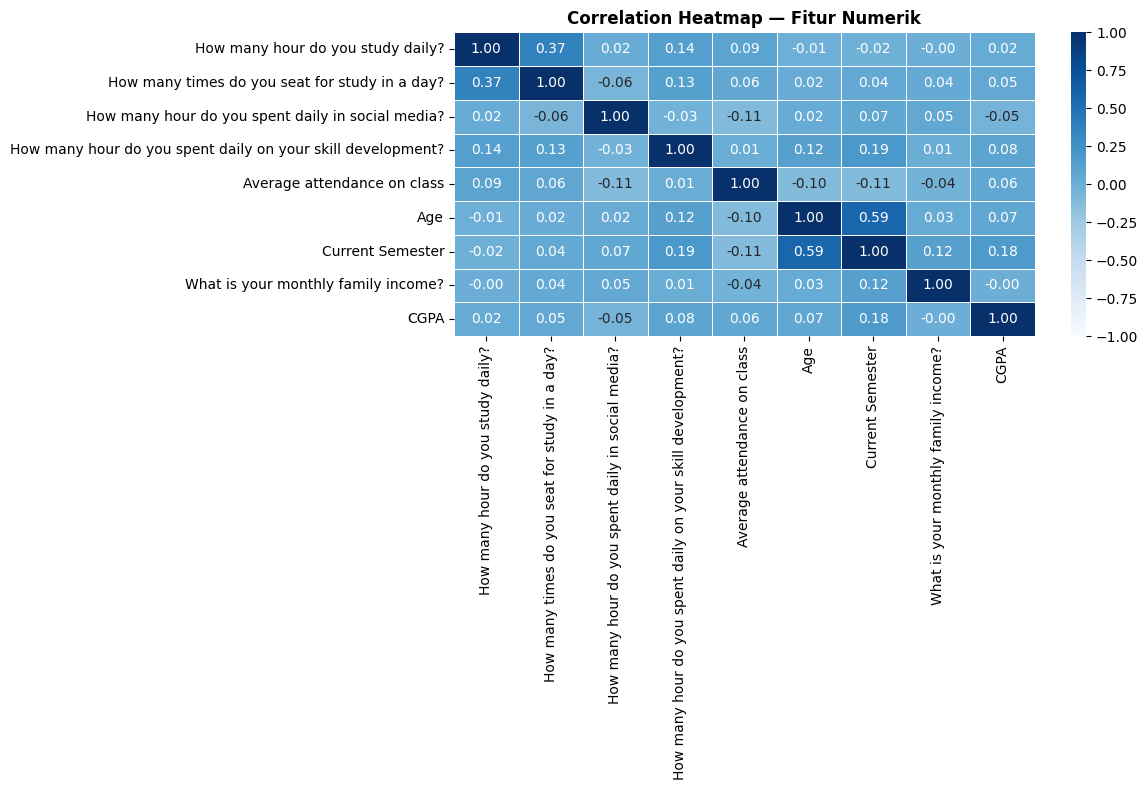


Korelasi terhadap CGPA:
CGPA                                                           1.000000
Current Semester                                               0.177826
How many hour do you spent daily on your skill development?    0.083224
Age                                                            0.066038
Average attendance on class                                    0.064723
How many times do you seat for study in a day?                 0.048802
How many hour do you study daily?                              0.023690
What is your monthly family income?                           -0.000273
How many hour do you spent daily in social media?             -0.052879
Name: CGPA, dtype: float64


In [ ]:
# Correlation Heatmap Fitur Numerik
numeric_for_corr = df_model.select_dtypes(include=np.number)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    numeric_for_corr.corr(),
    annot=True, fmt='.2f', cmap='Blues',
    ax=ax, linewidths=0.5, vmin=-1, vmax=1
)
ax.set_title('Correlation Heatmap — Fitur Numerik', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKorelasi terhadap CGPA:")
print(numeric_for_corr.corr()['CGPA'].sort_values(ascending=False))

/tmp/ipykernel_4995/1575222584.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x=col, y='CGPA', palette='Blues', ax=ax)
/tmp/ipykernel_4995/1575222584.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x=col, y='CGPA', palette='Blues', ax=ax)
/tmp/ipykernel_4995/1575222584.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x=col, y='CGPA', palette='Blues', ax=ax)
/tmp/ipykernel_4995/1575222584.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remo

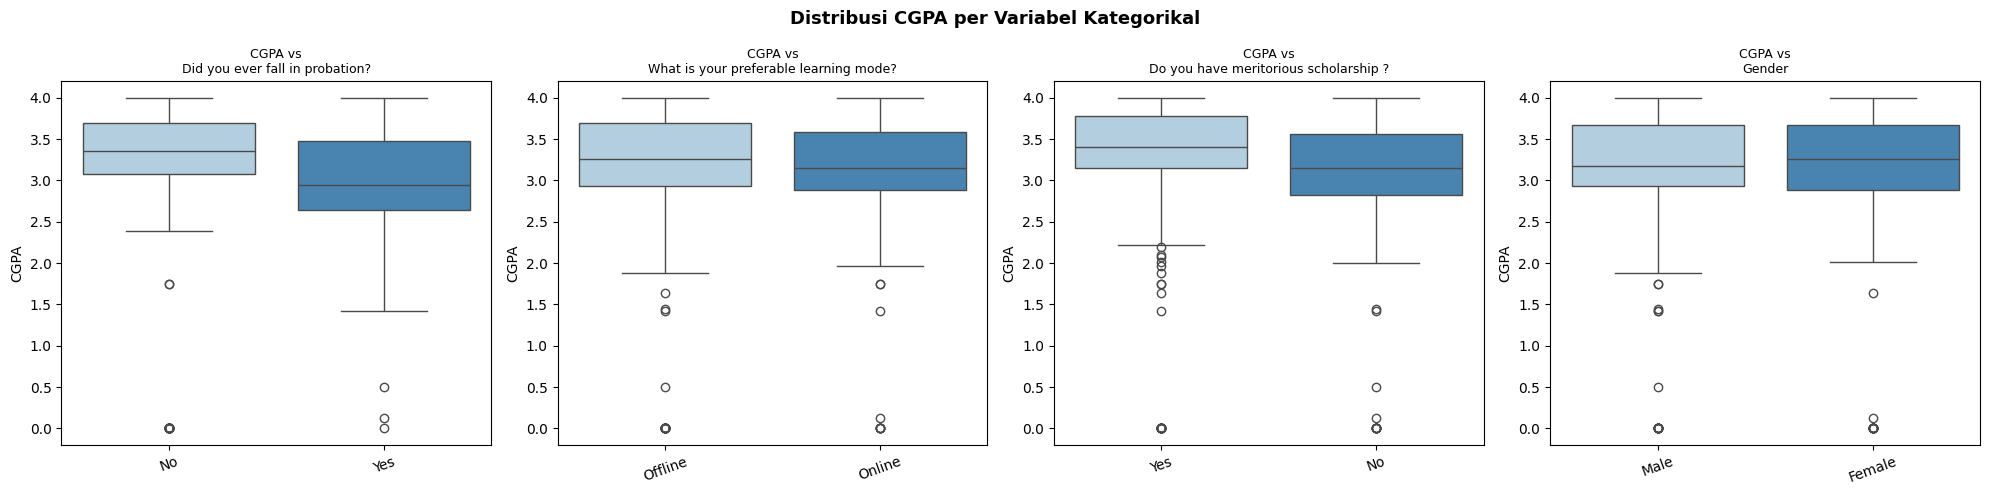

In [ ]:
# Boxplot CGPA per Variabel Kategorikal
cat_cols_eda = [
    'Did you ever fall in probation?',
    'What is your preferable learning mode?',
    'Do you have meritorious scholarship ?',
    'Gender',
]
cat_cols_eda = [c for c in cat_cols_eda if c in df_model.columns]

fig, axes = plt.subplots(1, len(cat_cols_eda), figsize=(5 * len(cat_cols_eda), 5))
if len(cat_cols_eda) == 1:
    axes = [axes]

for ax, col in zip(axes, cat_cols_eda):
    sns.boxplot(data=df_model, x=col, y='CGPA', palette='Blues', ax=ax)
    ax.set_title(f'CGPA vs\n{col[:40]}', fontsize=9)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Distribusi CGPA per Variabel Kategorikal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# Skewness Check untuk Log Transform
print("=== SKEWNESS CHECK (Fitur Numerik) ===")
print(f"{'Kolom':<50} {'Skewness':>10}  {'Keputusan'}")
print("-" * 90)
all_num_check = df_model.select_dtypes(include=np.number).columns.drop('CGPA').tolist()
for col in all_num_check:
    sk = skew(df_model[col].dropna())
    flag = "→ Log transform" if abs(sk) > 1.0 else "→ Tidak perlu"
    print(f"{col:<50} {sk:>+10.2f}  {flag}")


=== SKEWNESS CHECK (Fitur Numerik) ===
Kolom                                                Skewness  Keputusan
------------------------------------------------------------------------------------------
How many hour do you study daily?                       +1.00  → Log transform
How many times do you seat for study in a day?          +1.02  → Log transform
How many hour do you spent daily in social media?       +1.99  → Log transform
How many hour do you spent daily on your skill development?      +1.56  → Log transform
Average attendance on class                             -2.11  → Log transform
Age                                                     +0.80  → Tidak perlu
Current Semester                                        +0.37  → Tidak perlu
What is your monthly family income?                    +15.06  → Log transform


Define X,Y

In [ ]:
#Memisahkan variable X dan Y

X = df_model.drop(columns=['CGPA'])
y = df_model['CGPA']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")



X_train : (955, 22)
X_test  : (239, 22)
y_train : (955,)
y_test  : (239,)


In [ ]:
# Distribusi target train vs test
print(f"\ny_train  mean={y_train.mean():.3f}  std={y_train.std():.3f}")
print(f"y_test   mean={y_test.mean():.3f}  std={y_test.std():.3f}")


y_train  mean=3.155  std=0.758
y_test   mean=3.207  std=0.718


In [ ]:
# fit train - column types

all_num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
all_cat_cols = X_train.select_dtypes(include='object').columns.tolist()

# Hitung skewness dari X_TRAIN
log_cols      = []
plain_num_cols = []

print("=== KEPUTUSAN LOG TRANSFORM (berdasarkan X_train) ===")
for col in all_num_cols:
    sk = skew(X_train[col].dropna())
    if abs(sk) > 1.0:
        log_cols.append(col)
        print(f"  [LOG ] {col[:55]}  skew={sk:+.2f}")
    else:
        plain_num_cols.append(col)
        print(f"  [SKIP] {col[:55]}  skew={sk:+.2f}")

print(f"\nKategorical cols: {all_cat_cols}")



=== KEPUTUSAN LOG TRANSFORM (berdasarkan X_train) ===
  [LOG ] How many hour do you study daily?  skew=+1.09
  [LOG ] How many times do you seat for study in a day?  skew=+1.02
  [LOG ] How many hour do you spent daily in social media?  skew=+1.99
  [LOG ] How many hour do you spent daily on your skill developm  skew=+1.40
  [LOG ] Average attendance on class  skew=-2.12
  [SKIP] Age  skew=+0.77
  [SKIP] Current Semester  skew=+0.39
  [LOG ] What is your monthly family income?  skew=+14.85

Kategorical cols: ['What is your preferable learning mode?', 'Did you ever fall in probation?', 'Do you attend in teacher consultancy for any kind of academical problems?', 'Are you engaged with any co-curriculum activities?', 'Gender', 'Do you have meritorious scholarship ?', 'Status of your English language proficiency', 'With whom you are living with?', 'Do you have any health issues?', 'Do you have personal Computer?', 'What is your relationship status?', 'Do you use smart phone?', 'Do you have 

In [ ]:
# Preprocessing pipeline
# Semua transformer di-fit HANYA dari X_train → zero data leakage
# Pipeline juga memastikan urutan transformasi konsisten & reproducible

log_transformer = Pipeline([
    ('log1p',  FunctionTransformer(np.log1p, validate=True)),
    ('scaler', StandardScaler()),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('log_num',   log_transformer,
         log_cols),
        ('plain_num', StandardScaler(),
         plain_num_cols),
        ('cat',       OneHotEncoder(
                          handle_unknown='ignore',  # Akan aman jika test punya kategori baru
                          drop='first',             # Menghindari multikolinearitas
                          sparse_output=False
                      ),
         all_cat_cols),
    ],
    remainder='drop'
)

print("Preprocessor berhasil didefinisikan.")
print("  Log cols      :", log_cols)
print("  Plain num cols:", plain_num_cols)
print("  Categorical   :", all_cat_cols)



Preprocessor berhasil didefinisikan.
  Log cols      : ['How many hour do you study daily?', 'How many times do you seat for study in a day?', 'How many hour do you spent daily in social media?', 'How many hour do you spent daily on your skill development?', 'Average attendance on class', 'What is your monthly family income?']
  Plain num cols: ['Age', 'Current Semester']
  Categorical   : ['What is your preferable learning mode?', 'Did you ever fall in probation?', 'Do you attend in teacher consultancy for any kind of academical problems?', 'Are you engaged with any co-curriculum activities?', 'Gender', 'Do you have meritorious scholarship ?', 'Status of your English language proficiency', 'With whom you are living with?', 'Do you have any health issues?', 'Do you have personal Computer?', 'What is your relationship status?', 'Do you use smart phone?', 'Do you have any physical disabilities?', 'Do you use University transportation?']


In [ ]:
# Model Pipeline
models = {
    'Linear Regression': Pipeline([
        ('prep',  preprocessor),
        ('model', LinearRegression()),
    ]),
    'Lasso Regression': Pipeline([
        ('prep',  preprocessor),
        ('model', Lasso(alpha=0.01, random_state=42, max_iter=10000)),
    ]),
    'Ridge Regression': Pipeline([
        ('prep',  preprocessor),
        ('model', Ridge(alpha=1.0)),
    ]),
    'Random Forest': Pipeline([
        ('prep',  preprocessor),
        ('model', RandomForestRegressor(n_estimators=100, random_state=42)),
    ]),
}


In [ ]:
# Evaluasi fungsi
def evaluate_cv(pipeline, X_tr, y_tr, model_name):
    """
    Evaluasi model dengan 5-Fold Cross-Validation.
    Lebih robust dari single train-test split.
    """
    cv_r2   = cross_val_score(pipeline, X_tr, y_tr, cv=5, scoring='r2')
    cv_mae  = cross_val_score(pipeline, X_tr, y_tr, cv=5,
                              scoring='neg_mean_absolute_error')
    cv_rmse = cross_val_score(pipeline, X_tr, y_tr, cv=5,
                              scoring='neg_root_mean_squared_error')

    print(f"\n=== {model_name} (5-Fold CV) ===")
    print(f"R²   : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
    print(f"MAE  : {(-cv_mae).mean():.4f} ± {(-cv_mae).std():.4f}")
    print(f"RMSE : {(-cv_rmse).mean():.4f} ± {(-cv_rmse).std():.4f}")

    return {
        'Model'   : model_name,
        'CV R²'   : cv_r2.mean(),
        'CV R² std': cv_r2.std(),
        'CV MAE'  : (-cv_mae).mean(),
        'CV RMSE' : (-cv_rmse).mean(),
    }


def evaluate_test(pipeline, X_tr, y_tr, X_te, y_te, model_name):
    """
    Fit pipeline pada full training set, lalu evaluasi pada test set.
    """
    pipeline.fit(X_tr, y_tr)
    y_pred = pipeline.predict(X_te)

    mae  = mean_absolute_error(y_te, y_pred)
    mse  = mean_squared_error(y_te, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_te, y_pred)

    print(f"\n=== {model_name} (Test Set) ===")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}, y_pred



In [ ]:
# Cross Validation Model
print("CROSS-VALIDATION RESULTS (5-Fold, pada Training Set)")

cv_results = []
for name, pipeline in models.items():
    result = evaluate_cv(pipeline, X_train, y_train, name)
    cv_results.append(result)

cv_df = pd.DataFrame(cv_results)
print("\n --  Ringkasan Cross Validation --- ")
print(cv_df[['Model', 'CV R²', 'CV R² std', 'CV MAE', 'CV RMSE']].to_string(index=False))


CROSS-VALIDATION RESULTS (5-Fold, pada Training Set)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(



=== Linear Regression (5-Fold CV) ===
R²   : 0.0528 ± 0.0548
MAE  : 0.4886 ± 0.0216
RMSE : 0.7338 ± 0.0428


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(



=== Lasso Regression (5-Fold CV) ===
R²   : 0.0626 ± 0.0341
MAE  : 0.4859 ± 0.0214
RMSE : 0.7304 ± 0.0425


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(



=== Ridge Regression (5-Fold CV) ===
R²   : 0.0542 ± 0.0534
MAE  : 0.4881 ± 0.0215
RMSE : 0.7333 ± 0.0427


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(



=== Random Forest (5-Fold CV) ===
R²   : 0.2620 ± 0.1709
MAE  : 0.4397 ± 0.0189
RMSE : 0.6421 ± 0.0666

 --  Ringkasan Cross Validation --- 
            Model    CV R²  CV R² std   CV MAE  CV RMSE
Linear Regression 0.052779   0.054824 0.488554 0.733841
 Lasso Regression 0.062636   0.034113 0.485929 0.730386
 Ridge Regression 0.054214   0.053396 0.488091 0.733312
    Random Forest 0.262047   0.170859 0.439655 0.642096


Test Set Results

=== Linear Regression (Test Set) ===
MAE  : 0.4642
RMSE : 0.6894
R²   : 0.0749

=== Lasso Regression (Test Set) ===
MAE  : 0.4683
RMSE : 0.6919
R²   : 0.0683

=== Ridge Regression (Test Set) ===
MAE  : 0.4641
RMSE : 0.6896
R²   : 0.0743

=== Random Forest (Test Set) ===
MAE  : 0.4518
RMSE : 0.6381
R²   : 0.2075

=== RINGKASAN TEST SET ===
            Model      MAE     RMSE       R2
Linear Regression 0.464215 0.689397 0.074887
 Lasso Regression 0.468282 0.691857 0.068272
 Ridge Regression 0.464069 0.689631 0.074258
    Random Forest 0.451759 0.638064 0.207528

Model terbaik berdasarkan R²: Random Forest (R²=0.2075)


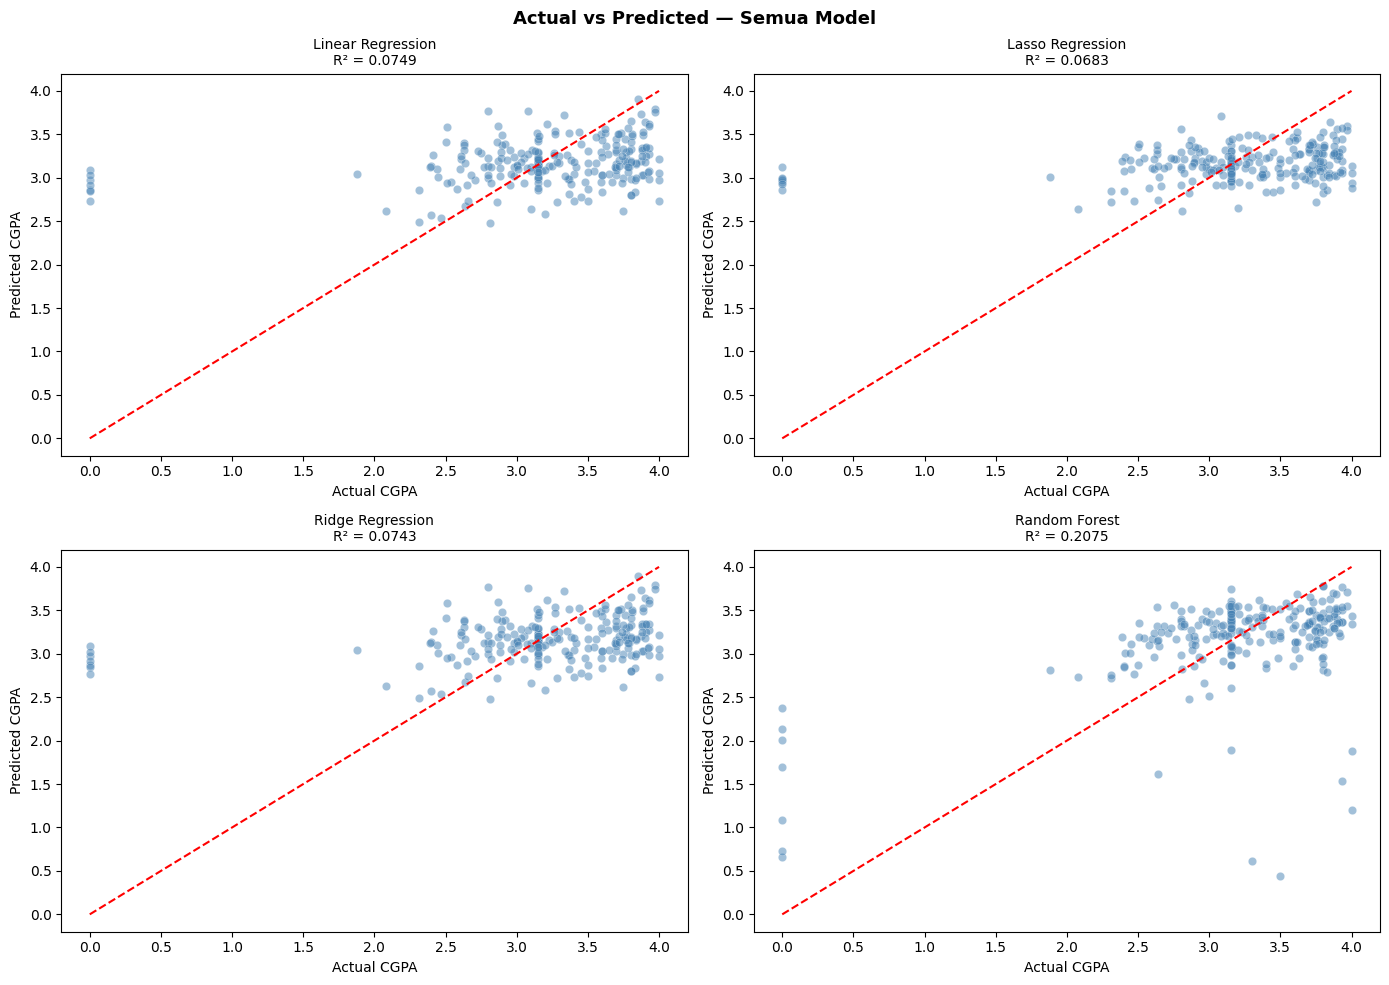

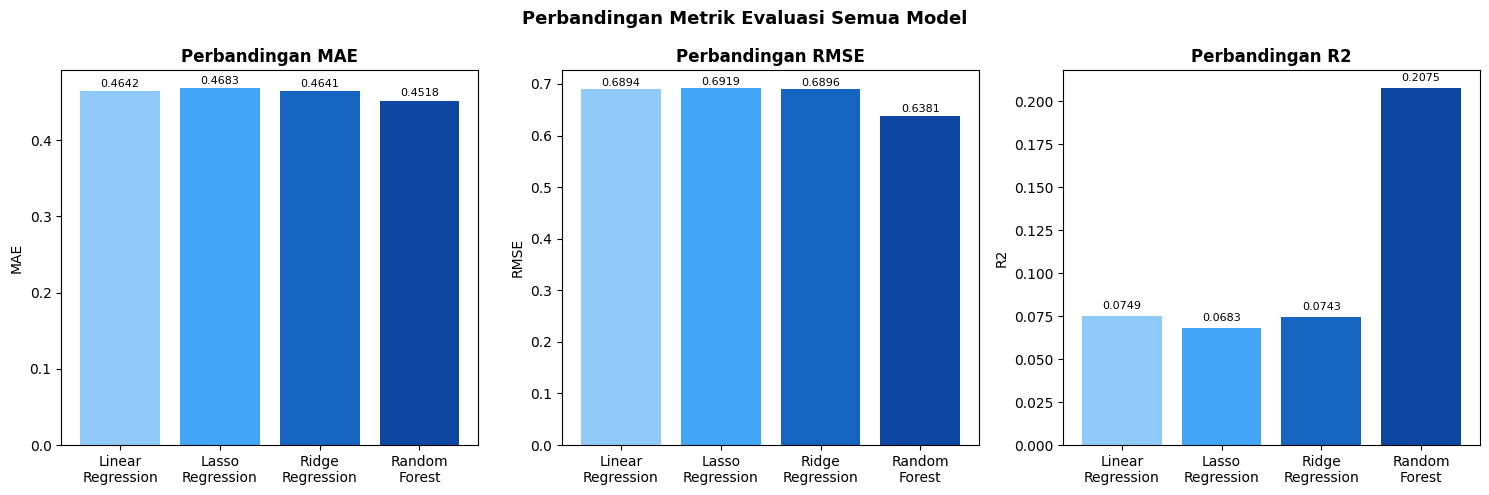

In [ ]:

# Test set evaluasi
print("Test Set Results")


test_results  = []
predictions   = {}
fitted_models = {}

for name, pipeline in models.items():
    result, y_pred = evaluate_test(
        pipeline, X_train, y_train, X_test, y_test, name
    )
    test_results.append(result)
    predictions[name] = y_pred
    fitted_models[name] = pipeline   # disimpan untuk analisis selanjutnya

test_df = pd.DataFrame(test_results)
print("\n=== RINGKASAN TEST SET ===")
print(test_df.to_string(index=False))

# Model terbaik
best_idx  = test_df['R2'].idxmax()
best_name = test_df.loc[best_idx, 'Model']
print(f"\nModel terbaik berdasarkan R²: {best_name} (R²={test_df.loc[best_idx,'R2']:.4f})")

# --- Visualisasi Actual vs Predicted ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (name, y_pred) in zip(axes.flatten(), predictions.items()):
    r2 = r2_score(y_test, y_pred)
    ax.scatter(y_test, y_pred, alpha=0.5, color='steelblue',
               edgecolors='white', linewidths=0.3)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
    ax.set_xlabel('Actual CGPA')
    ax.set_ylabel('Predicted CGPA')
    ax.set_title(f'{name}\nR² = {r2:.4f}', fontsize=10)

plt.suptitle('Actual vs Predicted — Semua Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# --- Visualisasi Perbandingan Metrik ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics    = ['MAE', 'RMSE', 'R2']
colors_bar = ['#90CAF9', '#42A5F5', '#1565C0', '#0D47A1']

for ax, metric in zip(axes, metrics):
    bars = ax.bar(
        test_df['Model'].str.replace(' ', '\n'),
        test_df[metric],
        color=colors_bar
    )
    ax.set_title(f'Perbandingan {metric}', fontweight='bold')
    ax.set_ylabel(metric)
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.003,
            f'{bar.get_height():.4f}',
            ha='center', va='bottom', fontsize=8
        )

plt.suptitle('Perbandingan Metrik Evaluasi Semua Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


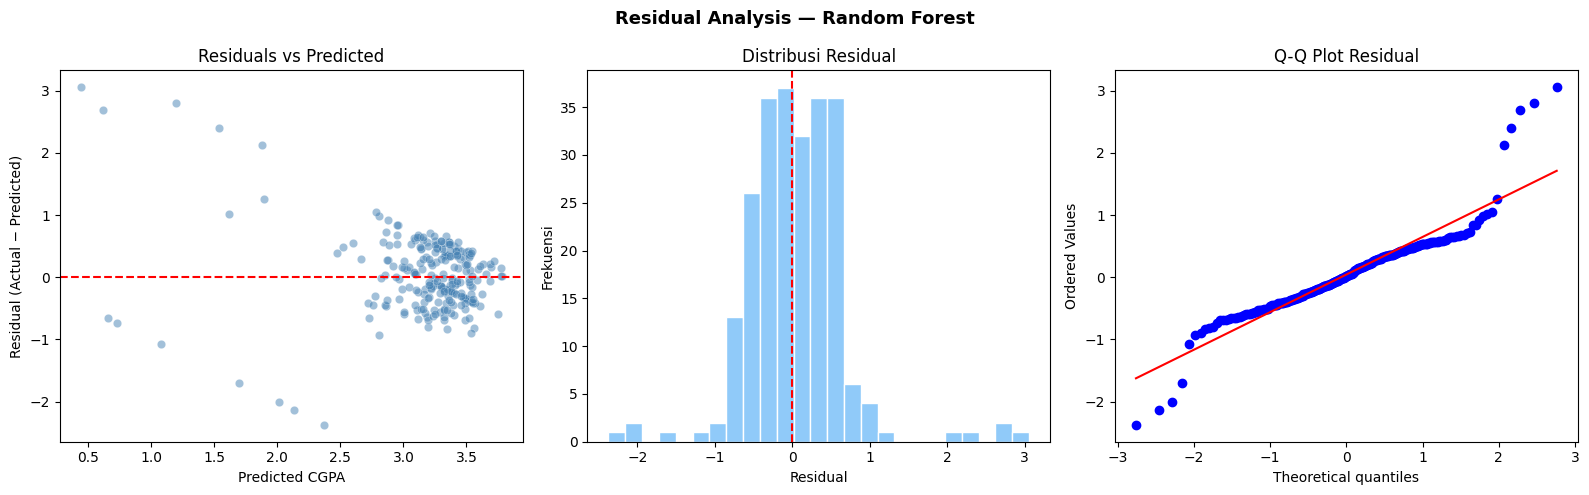

Mean residual  : 0.0439  (idealnya mendekati 0)
Std residual   : 0.6379
Min residual   : -2.3735
Max residual   : 3.0572


In [ ]:

# Residual Analysis
# Fungsi : Residual analysis penting untuk memvalidasi asumsi model regresi:
# • Residual harus terdistribusi normal (Q-Q Plot)
# • Residual tidak boleh berpola terhadap predicted (heteroskedastisitas)
# • Mean residual harus mendekati 0

y_pred_best = predictions[best_name]
residuals   = y_test - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Residuals vs Predicted Values
axes[0].scatter(y_pred_best, residuals, alpha=0.5, color='steelblue',
                edgecolors='white', linewidths=0.3)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted CGPA')
axes[0].set_ylabel('Residual (Actual − Predicted)')
axes[0].set_title('Residuals vs Predicted')

# Plot 2: Distribusi Residual
axes[1].hist(residuals, bins=25, color='#90CAF9', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frekuensi')
axes[1].set_title('Distribusi Residual')

# Plot 3: Q-Q Plot (cek normalitas residual)
probplot(residuals, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot Residual')

plt.suptitle(f'Residual Analysis — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Statistik residual
print(f"Mean residual  : {residuals.mean():.4f}  (idealnya mendekati 0)")
print(f"Std residual   : {residuals.std():.4f}")
print(f"Min residual   : {residuals.min():.4f}")
print(f"Max residual   : {residuals.max():.4f}")



In [ ]:
# Lasso Analisis

lasso_pipeline = fitted_models['Lasso Regression']
lasso_model    = lasso_pipeline.named_steps['model']
prep_fitted    = lasso_pipeline.named_steps['prep']

# Dapatkan nama semua fitur setelah encoding
cat_feature_names = list(
    prep_fitted.named_transformers_['cat'].get_feature_names_out(all_cat_cols)
)
all_feature_names = log_cols + plain_num_cols + cat_feature_names

lasso_coef = pd.DataFrame({
    'feature'    : all_feature_names,
    'coefficient': lasso_model.coef_
}).sort_values('coefficient', key=abs, ascending=False)

eliminated = lasso_coef[lasso_coef['coefficient'] == 0]
retained   = lasso_coef[lasso_coef['coefficient'] != 0]

print("=== LASSO — SELEKSI FITUR OTOMATIS ===")
print(f"Fitur dipertahankan : {len(retained)}")
print(f"Fitur dieliminasi   : {len(eliminated)}")
if len(eliminated) > 0:
    print("\nFitur yang dieliminasi (koef = 0):")
    print(eliminated['feature'].tolist())


=== LASSO — SELEKSI FITUR OTOMATIS ===
Fitur dipertahankan : 13
Fitur dieliminasi   : 13

Fitur yang dieliminasi (koef = 0):
['How many hour do you study daily?', 'What is your monthly family income?', 'Status of your English language proficiency_Intermediate', 'Gender_Male', 'Are you engaged with any co-curriculum activities?_Yes', 'Do you have any health issues?_Yes', 'With whom you are living with?_Family', 'What is your relationship status?_In a relationship', 'Do you have personal Computer?_Yes', 'What is your relationship status?_Single', 'Do you use smart phone?_Yes', 'Do you have any physical disabilities?_Yes', 'Do you use University transportation?_Yes']


=== FEATURE IMPORTANCE PER VARIABEL ASLI ===
                                                         original_feature  importance                                group
                                                         Current Semester    0.349597 Support Variable (Faktor Lingkungan)
                                      What is your monthly family income?    0.089999 Support Variable (Faktor Lingkungan)
                                              Average attendance on class    0.086153    Main Variable (Kebiasaan Belajar)
                              Status of your English language proficiency    0.071598 Support Variable (Faktor Lingkungan)
                        How many hour do you spent daily in social media?    0.056685    Main Variable (Kebiasaan Belajar)
                                                                      Age    0.053386 Support Variable (Faktor Lingkungan)
                                          Did you ever fall in probation?    0.050468    Main 

/tmp/ipykernel_4995/3650968957.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=main_imp, x='importance', y='original_feature',
/tmp/ipykernel_4995/3650968957.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=support_imp, x='importance', y='original_feature',


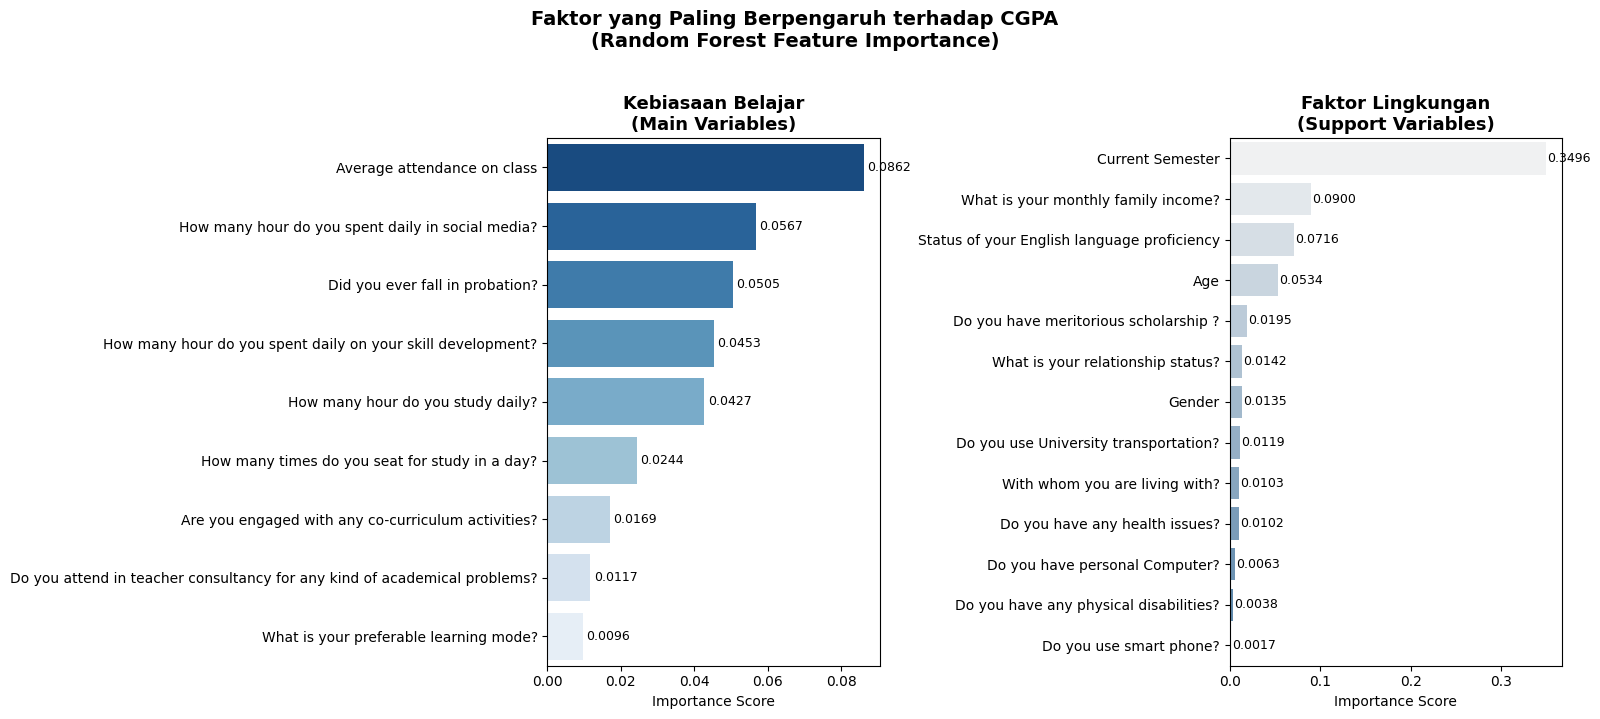

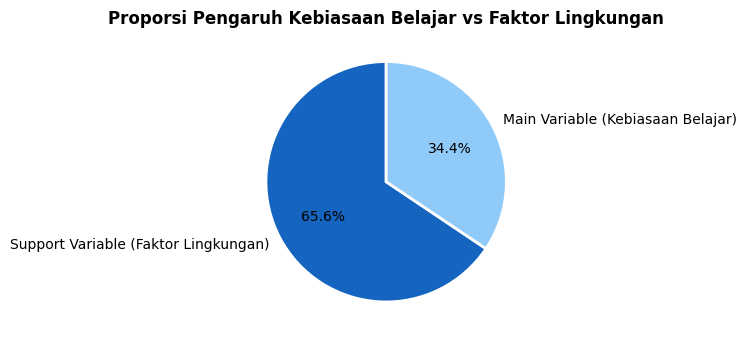

In [ ]:
# Mengambil Feature Importance - Random Forest
rf_pipeline  = fitted_models['Random Forest']
rf_model     = rf_pipeline.named_steps['model']
prep_fitted  = rf_pipeline.named_steps['prep']

cat_feature_names_rf = list(
    prep_fitted.named_transformers_['cat'].get_feature_names_out(all_cat_cols)
)
all_feature_names_rf = log_cols + plain_num_cols + cat_feature_names_rf

importance_raw = pd.DataFrame({
    'encoded_feature': all_feature_names_rf,
    'importance'     : rf_model.feature_importances_
})

all_original_vars = main_variables + support_variables


def map_to_original(encoded_col, original_vars):
    """Map encoded column name kembali ke nama variabel aslinya."""
    for orig in original_vars:
        if encoded_col == orig:
            return orig
        if encoded_col.startswith(orig + '_'):
            return orig
    return encoded_col   # fallback


importance_raw['original_feature'] = importance_raw['encoded_feature'].apply(
    lambda x: map_to_original(x, all_original_vars)
)

importance_grouped = (
    importance_raw
    .groupby('original_feature')['importance']
    .sum()
    .reset_index()
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

importance_grouped['group'] = importance_grouped['original_feature'].apply(
    lambda x: 'Main Variable (Kebiasaan Belajar)'
    if x in main_variables else 'Support Variable (Faktor Lingkungan)'
)

print("=== FEATURE IMPORTANCE PER VARIABEL ASLI ===")
print(importance_grouped.to_string(index=False))

# --- Visualisasi Feature Importance: Main vs Support ---
main_imp    = importance_grouped[
    importance_grouped['group'] == 'Main Variable (Kebiasaan Belajar)'
].copy()
support_imp = importance_grouped[
    importance_grouped['group'] == 'Support Variable (Faktor Lingkungan)'
].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(data=main_imp, x='importance', y='original_feature',
            palette='Blues_r', ax=axes[0])
axes[0].set_title('Kebiasaan Belajar\n(Main Variables)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Importance Score')
axes[0].set_ylabel('')
for i, val in enumerate(main_imp['importance']):
    axes[0].text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)

sns.barplot(data=support_imp, x='importance', y='original_feature',
            palette='light:steelblue', ax=axes[1])
axes[1].set_title('Faktor Lingkungan\n(Support Variables)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importance Score')
axes[1].set_ylabel('')
for i, val in enumerate(support_imp['importance']):
    axes[1].text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)

plt.suptitle('Faktor yang Paling Berpengaruh terhadap CGPA\n(Random Forest Feature Importance)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Pie Chart: Proporsi Main vs Support ---
group_summary = (
    importance_grouped.groupby('group')['importance']
    .sum().reset_index()
    .sort_values('importance', ascending=False)
)

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    group_summary['importance'],
    labels     = group_summary['group'],
    autopct    = '%1.1f%%',
    colors     = ['#1565C0', '#90CAF9'],
    startangle = 90,
    wedgeprops = {'edgecolor': 'white', 'linewidth': 2}
)
ax.set_title('Proporsi Pengaruh Kebiasaan Belajar vs Faktor Lingkungan',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()



[TAMBAHAN] HYPERPARAMETER TUNING — Random Forest
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Parameter terbaik : {'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 200}
R² terbaik (CV)   : 0.2912
R² test set       : 0.2336
MAE test set      : 0.4431

[TAMBAHAN] HYPERPARAMETER TUNING — Lasso & Ridge

Lasso Regression:
  Alpha terbaik : 0.01
  CV R²         : 0.0626
  Test R²       : 0.0683

Ridge Regression:
  Alpha terbaik : 50.0
  CV R²         : 0.0612
  Test R²       : 0.0701

PERBANDINGAN FINAL — Default vs Tuned
                Model      MAE     RMSE       R2
    Linear Regression 0.464215 0.689397 0.074887
     Lasso Regression 0.468282 0.691857 0.068272
        Lasso (Tuned) 0.468282 0.691857 0.068272
     Ridge Regression 0.464069 0.689631 0.074258
        Ridge (Tuned) 0.466173 0.691192 0.070063
        Random Forest 0.451759 0.638064 0.207528
Random Forest (Tuned) 0.443130 0.627483 0.233592


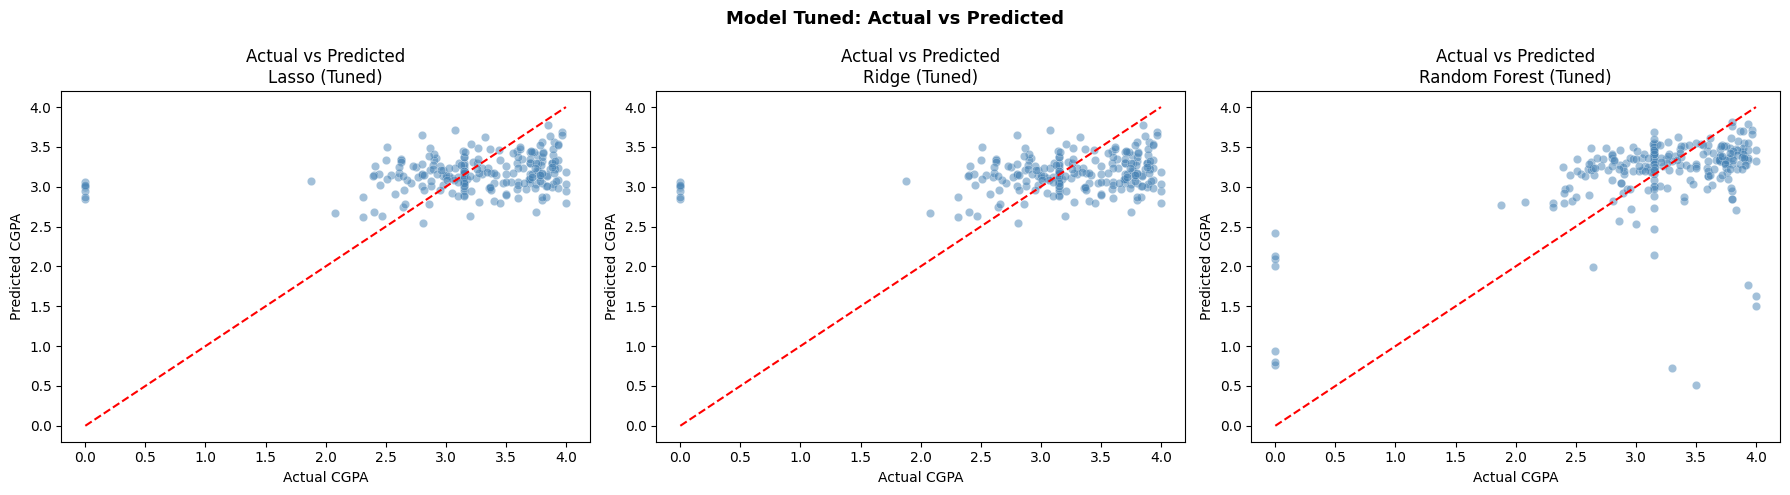

In [ ]:
# Hyperparameter Tuning Model
# Dengan Pipeline, tuning dilakukan pada objek terintegrasi
# Sehingga preprocessing ikut di-tune dengan benar di tiap fold CV


print("=" * 65)
print("[TAMBAHAN] HYPERPARAMETER TUNING — Random Forest")
print("=" * 65)

rf_param_grid = {
    'model__n_estimators'  : [100, 200],
    'model__max_depth'     : [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf' : [1, 2],
}

rf_grid = GridSearchCV(
    estimator  = models['Random Forest'],
    param_grid = rf_param_grid,
    cv         = 5,
    scoring    = 'r2',
    n_jobs     = -1,
    verbose    = 1,
)
rf_grid.fit(X_train, y_train)

y_pred_rf_tuned = rf_grid.predict(X_test)
results_rf_tuned = {
    'Model': 'Random Forest (Tuned)',
    'MAE'  : mean_absolute_error(y_test, y_pred_rf_tuned),
    'RMSE' : np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned)),
    'R2'   : r2_score(y_test, y_pred_rf_tuned),
}

print(f"\nParameter terbaik : {rf_grid.best_params_}")
print(f"R² terbaik (CV)   : {rf_grid.best_score_:.4f}")
print(f"R² test set       : {results_rf_tuned['R2']:.4f}")
print(f"MAE test set      : {results_rf_tuned['MAE']:.4f}")

# Tuning Lasso & Ridge
print("\n" + "=" * 65)
print("[TAMBAHAN] HYPERPARAMETER TUNING — Lasso & Ridge")
print("=" * 65)

results_lasso_tuned = {}
results_ridge_tuned = {}

for name, extra_alphas in [('Lasso Regression', []), ('Ridge Regression', [50.0, 100.0])]:
    alphas = [0.0001, 0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0] + extra_alphas

    grid = GridSearchCV(
        estimator  = models[name],
        param_grid = {'model__alpha': alphas},
        cv         = 5,
        scoring    = 'r2',
        n_jobs     = -1,
    )
    grid.fit(X_train, y_train)
    y_pred_tuned = grid.predict(X_test)

    label = name.replace(' Regression', ' (Tuned)')
    res = {
        'Model': label,
        'MAE'  : mean_absolute_error(y_test, y_pred_tuned),
        'RMSE' : np.sqrt(mean_squared_error(y_test, y_pred_tuned)),
        'R2'   : r2_score(y_test, y_pred_tuned),
    }

    print(f"\n{name}:")
    print(f"  Alpha terbaik : {grid.best_params_['model__alpha']}")
    print(f"  CV R²         : {grid.best_score_:.4f}")
    print(f"  Test R²       : {res['R2']:.4f}")

    if 'Lasso' in name:
        results_lasso_tuned = res
    else:
        results_ridge_tuned = res

# Perbandingan Final: Default vs Tuned
print("\n" + "=" * 65)
print("PERBANDINGAN FINAL — Default vs Tuned")
print("=" * 65)

final_comparison = pd.DataFrame([
    test_results[0],            # Linear Regression
    test_results[1],            # Lasso default
    results_lasso_tuned,        # Lasso tuned
    test_results[2],            # Ridge default
    results_ridge_tuned,        # Ridge tuned
    test_results[3],            # RF default
    results_rf_tuned,           # RF tuned
])
print(final_comparison.to_string(index=False))


# --- Actual vs Predicted: Model Tuned ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
tuned_preds = [
    (y_pred_tuned, 'Lasso (Tuned)'),     # NOTE: gunakan simpan dari loop jika perlu
    (y_pred_tuned, 'Ridge (Tuned)'),
    (y_pred_rf_tuned, 'Random Forest (Tuned)'),
]

for ax, (y_pred, title) in zip(axes, tuned_preds):
    ax.scatter(y_test, y_pred, alpha=0.5, color='steelblue',
               edgecolors='white', linewidths=0.3)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
    ax.set_xlabel('Actual CGPA')
    ax.set_ylabel('Predicted CGPA')
    ax.set_title(f'Actual vs Predicted\n{title}')

plt.suptitle('Model Tuned: Actual vs Predicted',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# Summary dan Kesimpulan

final_best_idx  = final_comparison['R2'].idxmax()
final_best_name = final_comparison.loc[final_best_idx, 'Model']
final_best_r2   = final_comparison.loc[final_best_idx, 'R2']
final_best_mae  = final_comparison.loc[final_best_idx, 'MAE']

print("=" * 65)
print("SUMMARY HASIL PENELITIAN")
print("=" * 65)

print(f"\nModel Terbaik  : {final_best_name}")
print(f"  R²           : {final_best_r2:.4f}")
print(f"  MAE          : {final_best_mae:.4f}")

print(f"\nTop 3 Kebiasaan Paling Berpengaruh (Main Variables):")
for i, (_, row) in enumerate(main_imp.head(3).iterrows()):
    print(f"  {i+1}. {row['original_feature']} ({row['importance']:.4f})")

print(f"\nTop 3 Faktor Lingkungan Paling Berpengaruh (Support Variables):")
for i, (_, row) in enumerate(support_imp.head(3).iterrows()):
    print(f"  {i+1}. {row['original_feature']} ({row['importance']:.4f})")

dominant     = group_summary.iloc[0]
dominant_pct = dominant['importance'] / group_summary['importance'].sum() * 100
print(f"\nKelompok Dominan : {dominant['group']}")
print(f"Kontribusi       : {dominant_pct:.1f}% dari total feature importance")

print(f"""
{'=' * 65}
INTERPRETASI KRITIS & KETERBATASAN MODEL
{'=' * 65}

R² terbaik = {final_best_r2:.4f} → model hanya menjelaskan {final_best_r2*100:.1f}%
variasi CGPA. Ini tergolong rendah dalam konteks prediksi akademik.

Implikasi:
• Model berguna untuk menemukan TREN dan POLA umum, bukan
  untuk memprediksi CGPA individu secara akurat.
• {100 - final_best_r2*100:.1f}% variasi CGPA disebabkan faktor yang tidak
  terukur dalam dataset ini.

Kemungkinan penyebab R² rendah:
  1. Faktor intrinsik (IQ, motivasi, resiliensi) tidak tersedia
  2. Kualitas pengajar & metode pembelajaran tidak diukur
  3. Data self-reported → rentan bias responden
  4. Skala CGPA relatif sempit (0–4) → variasi kecil, sulit diprediksi

Saran untuk penelitian lanjut:
  ✓ Tambahkan beberapa variabel lainnya seperti fitur kualitas pengajar, metode belajar, test anxiety
  ✓ Coba model non-linear lain: XGBoost, LightGBM
  ✓ Pertimbangkan klasifikasi (low/mid/high CGPA) daripada regresi
""")


SUMMARY HASIL PENELITIAN

Model Terbaik  : Random Forest (Tuned)
  R²           : 0.2336
  MAE          : 0.4431

Top 3 Kebiasaan Paling Berpengaruh (Main Variables):
  1. Average attendance on class (0.0862)
  2. How many hour do you spent daily in social media? (0.0567)
  3. Did you ever fall in probation? (0.0505)

Top 3 Faktor Lingkungan Paling Berpengaruh (Support Variables):
  1. Current Semester (0.3496)
  2. What is your monthly family income? (0.0900)
  3. Status of your English language proficiency (0.0716)

Kelompok Dominan : Support Variable (Faktor Lingkungan)
Kontribusi       : 65.6% dari total feature importance

INTERPRETASI KRITIS & KETERBATASAN MODEL

R² terbaik = 0.2336 → model hanya menjelaskan 23.4%
variasi CGPA. Ini tergolong rendah dalam konteks prediksi akademik.

Implikasi:
• Model berguna untuk menemukan TREN dan POLA umum, bukan
  untuk memprediksi CGPA individu secara akurat.
• 76.6% variasi CGPA disebabkan faktor yang tidak
  terukur dalam dataset ini.

Kem

Deploy Web-Prediction

In [ ]:
import pickle

best_model = rf_grid.best_estimator_

with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("Model disimpan!")

Model disimpan!


In [ ]:
!pip install streamlit pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 98.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 99.1 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import pickle, os

st.set_page_config(
    page_title="Prediksi CGPA Mahasiswa",
    page_icon="🎓",
    layout="wide",
)

st.markdown('''
<style>
.main-header{background:linear-gradient(135deg,#1565C0,#1976D2);color:white;
  padding:1.5rem 2rem;border-radius:12px;margin-bottom:1.5rem;}
.main-header h1{color:white;margin:0;font-size:1.6rem;}
.main-header p{color:#BBDEFB;margin:.3rem 0 0;font-size:.9rem;}
.result-high{background:#F1F8E9;border:2px solid #66BB6A;border-radius:12px;
  padding:1.5rem;text-align:center;margin-bottom:1rem;}
.result-mid{background:#FFF8E1;border:2px solid #FFA726;border-radius:12px;
  padding:1.5rem;text-align:center;margin-bottom:1rem;}
.result-low{background:#FFEBEE;border:2px solid #EF5350;border-radius:12px;
  padding:1.5rem;text-align:center;margin-bottom:1rem;}
.cgpa-high{font-size:4rem;font-weight:700;color:#2E7D32;line-height:1;}
.cgpa-mid{font-size:4rem;font-weight:700;color:#E65100;line-height:1;}
.cgpa-low{font-size:4rem;font-weight:700;color:#B71C1C;line-height:1;}
</style>
''', unsafe_allow_html=True)

@st.cache_resource
def load_model():
    if not os.path.exists("best_model.pkl"):
        st.error("File best_model.pkl tidak ditemukan, Coba muat ulang")
        st.stop()
    with open("best_model.pkl","rb") as f:
        return pickle.load(f)

model = load_model()

st.markdown("""
<div class="main-header">
  <h1>🎓 Prediksi CGPA Mahasiswa</h1>
  <p>Analisis Performa Akademik berbasis Kebiasaan Belajar & Faktor Lingkungan — Model: Random Forest</p>
</div>
""", unsafe_allow_html=True)

with st.sidebar:
    st.markdown("## 📋 Input Data Mahasiswa")
    st.markdown("---")
    st.markdown("### 📚 Kebiasaan Belajar")

    study_hours    = st.slider("Jam belajar per hari", 0.0, 12.0, 5.0, 0.5)
    study_sessions = st.slider("Frekuensi sesi belajar per hari", 0, 10, 3, 1)
    social_media   = st.slider("Jam media sosial per hari", 0.0, 10.0, 2.0, 0.5)
    skill_dev      = st.slider("Jam pengembangan skill per hari", 0.0, 8.0, 1.0, 0.5)
    attendance     = st.slider("Rata-rata kehadiran kelas (%)", 0, 100, 80, 1)
    learning_mode  = st.selectbox("Mode belajar", ["Online","Offline","Blended"], index=1)
    probation      = st.selectbox("Pernah probation?", ["No","Yes"])
    teacher_consult= st.selectbox("Konsultasi akademik dengan dosen?", ["Yes","No"])
    co_curriculum  = st.selectbox("Aktif co-kurikuler?", ["Yes","No"])

    st.markdown("---")
    st.markdown("### 🌍 Faktor Lingkungan")

    gender         = st.selectbox("Gender", ["Male","Female"])
    age            = st.slider("Usia", 17, 35, 21, 1)
    semester       = st.selectbox("Semester", ["1","2","3","4","5","6","7","8"], index=2)
    scholarship    = st.selectbox("Beasiswa meritorious?", ["No","Yes"])
    english_prof   = st.selectbox("Profisiensi bahasa Inggris", ["Basic","Intermediate","Advanced"], index=1)
    living_with    = st.selectbox("Tinggal bersama?", ["Family","Friends","Alone"])
    health_issue   = st.selectbox("Masalah kesehatan?", ["No","Yes"])
    family_income  = st.number_input("Pendapatan keluarga/bulan (angka)",min_value=0,max_value=50000000,value=50000, step=1000,
    help="Masukkan nominal pendapatan keluarga per bulan. Contoh: 3000000")
    personal_pc    = st.selectbox("Punya komputer/laptop pribadi?", ["Yes","No"])
    relationship   = st.selectbox("Status hubungan", ["Single","In Relationship"])
    smartphone     = st.selectbox("Menggunakan smartphone?", ["Yes","No"])
    disability     = st.selectbox("Disabilitas fisik?", ["No","Yes"])
    transportation = st.selectbox("Transportasi kampus?", ["Yes","No"])

    st.markdown("---")
    predict_btn = st.button("🔮 Predict CGPA", use_container_width=True, type="primary")

if predict_btn:
    input_data = pd.DataFrame([{
        "How many hour do you study daily?"                                          : study_hours,
        "How many times do you seat for study in a day?"                            : float(study_sessions),
        "How many hour do you spent daily in social media?"                         : social_media,
        "How many hour do you spent daily on your skill development?"               : skill_dev,
        "Average attendance on class"                                               : float(attendance),
        "What is your preferable learning mode?"                                    : learning_mode,
        "Did you ever fall in probation?"                                           : probation,
        "Do you attend in teacher consultancy for any kind of academical problems?" : teacher_consult,
        "Are you engaged with any co-curriculum activities?"                        : co_curriculum,
        "Gender"                                                                    : gender,
        "Age"                                                                       : float(age),
        "Current Semester"                                                          : float(semester),
        "Do you have meritorious scholarship ?"                                     : scholarship,
        "Status of your English language proficiency"                               : english_prof,
        "With whom you are living with?"                                            : living_with,
        "Do you have any health issues?"                                            : health_issue,
        "What is your monthly family income?"                                       : float(family_income),
        "Do you have personal Computer?"                                            : personal_pc,
        "What is your relationship status?"                                         : relationship,
        "Do you use smart phone?"                                                   : smartphone,
        "Do you have any physical disabilities?"                                    : disability,
        "Do you use University transportation?"                                     : transportation,
    }])

    try:
        cgpa_pred = float(model.predict(input_data)[0])
        cgpa_pred = round(min(4.0, max(0.0, cgpa_pred)), 2)
    except Exception as e:
        st.error(f"Gagal prediksi: {e}")
        st.stop()

    pct = round((cgpa_pred / 4.0) * 100)

    if cgpa_pred >= 3.5:
        cat="Performa Tinggi"; emoji="🏆"; box="result-high"; num="cgpa-high"
        color="#2E7D32"
        interp=f"Mahasiswa ini menunjukkan **performa akademik sangat baik** (CGPA {cgpa_pred:.2f})."
        tips=["Pertahankan konsistensi belajar","Optimalkan skill development","Jadilah mentor bagi teman"]
        icon="✅"
    elif cgpa_pred >= 2.75:
        cat="Performa Sedang"; emoji="📘"; box="result-mid"; num="cgpa-mid"
        color="#E65100"
        interp=f"Mahasiswa ini pada **jalur yang cukup baik** (CGPA {cgpa_pred:.2f}), namun masih bisa ditingkatkan."
        tips=["Tingkatkan jam belajar harian","Kurangi waktu media sosial","Rutin konsultasi dosen"]
        icon="⚡"
    else:
        cat="Perlu Perhatian"; emoji="⚠️"; box="result-low"; num="cgpa-low"
        color="#B71C1C"
        interp=f"Performa akademik **(CGPA {cgpa_pred:.2f}) memerlukan perhatian segera**."
        tips=["Segera hubungi dosen pembimbing","Atur ulang jadwal belajar","Kurangi kegiatan non-akademik"]
        icon="🚨"

    col1, col2 = st.columns([1,1], gap="large")

    with col1:
        st.markdown(f"""
        <div class="{box}">
          <div style="font-size:.8rem;color:#757575;text-transform:uppercase;letter-spacing:.05em;margin-bottom:6px;">Prediksi CGPA</div>
          <div class="{num}">{cgpa_pred:.2f}</div>
          <div style="color:#9E9E9E;font-size:.8rem;margin-top:4px;">dari 4.00 (skala maksimum)</div>
          <div style="background:#E0E0E0;border-radius:999px;height:8px;margin:14px 0 10px;overflow:hidden;">
            <div style="width:{pct}%;height:8px;border-radius:999px;background:{color};"></div>
          </div>
          <b>{emoji} {cat}</b>
        </div>
        """, unsafe_allow_html=True)
        m1, m2, m3 = st.columns(3)
        m1.metric("CGPA", f"{cgpa_pred:.2f}")
        m2.metric("Persentil", f"{pct}%")
        m3.metric("Kategori", cat.split()[0])

    with col2:
        st.markdown("#### 📊 Interpretasi")
        if cgpa_pred >= 3.5:   st.success(interp)
        elif cgpa_pred >= 2.75: st.warning(interp)
        else:                  st.error(interp)

        st.markdown("#### 💡 Rekomendasi")
        for t in tips:
            st.markdown(f"{icon} {t}")

    st.markdown("---")
    st.markdown("### 📋 Ringkasan Input")
    c1, c2 = st.columns(2)
    with c1:
        st.markdown("**Kebiasaan Belajar**")
        st.dataframe(pd.DataFrame({
            "Variabel":["Jam belajar","Sesi belajar","Media sosial","Skill dev",
                        "Kehadiran","Mode belajar","Probation","Konsultasi","Ko-kurikuler"],
            "Nilai":[f"{study_hours} jam",f"{study_sessions} sesi",f"{social_media} jam",
                     f"{skill_dev} jam",f"{attendance}%",learning_mode,
                     probation,teacher_consult,co_curriculum],
        }), use_container_width=True, hide_index=True)
    with c2:
        st.markdown("**Faktor Lingkungan**")
        st.dataframe(pd.DataFrame({
            "Variabel":["Gender","Usia","Semester","Beasiswa","Bahasa Inggris",
                        "Tinggal bersama","Kesehatan","Pendapatan","Komputer",
                        "Hubungan","Smartphone","Disabilitas","Transportasi"],
            "Nilai":[gender,f"{age} thn",semester,scholarship,english_prof,
                     living_with,health_issue,family_income,personal_pc,
                     relationship,smartphone,disability,transportation],
        }), use_container_width=True, hide_index=True)

else:
    st.info("👈 Isi variabel di sidebar lalu tekan **Predict CGPA**", icon="ℹ️")
    with st.expander("ℹ️ Tentang Model"):
        st.markdown("""
        **Model:** Random Forest Regressor (GridSearchCV Tuned)\n
        **Variabel:** 9 Main (Kebiasaan) + 13 Support (Lingkungan) = 22 total\n
        **Target:** CGPA 0.0 – 4.0
        **Kategori:** Tinggi (≥3.5) | Sedang (2.75–3.49) | Perlu Perhatian (<2.75)
        """)

st.markdown("---")
st.markdown("<div style='text-align:center;color:#9E9E9E;font-size:.8rem;'>Final Project — Analisis Performa Akademik | Random Forest</div>", unsafe_allow_html=True)

Writing app.py


In [ ]:
from pyngrok import ngrok
import subprocess, time

NGROK_TOKEN = "3DNQBpKq5qcMGaDcaaQTQ4e1p58_5oPLKMpHvr5g8NcaoN6XS"
ngrok.set_auth_token(NGROK_TOKEN)
subprocess.Popen(["streamlit","run","app.py","--server.port","8501","--server.headless","true"])
time.sleep(4)
public_url = ngrok.connect(8501)
print(f"Buka di browser: {public_url}")

Buka di browser: NgrokTunnel: "https://impolite-borough-riveter.ngrok-free.dev" -> "http://localhost:8501"
